In [1]:
import cv2
import numpy as np

# Read image as grayscale
img = cv2.imread("apple.jpg", 0)

# Calculate gradient in X and Y directions
Gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
Gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

# Calculate magnitude (strength)
magnitude = np.sqrt(Gx**2 + Gy**2)

# Calculate orientation (angle)
# used to reprenr in degree
angle = np.degrees(np.arctan2(Gy, Gx))

# Pick one pixel
x = 100
y = 100

print("Gx =", Gx[y, x])
print("Gy =", Gy[y, x])
print("Strength =", magnitude[y, x])
print("Angle =", angle[y, x], "degrees")

Gx = -7.0
Gy = -13.0
Strength = 14.7648230602334
Angle = -118.30075576600638 degrees


In [2]:
import cv2
import numpy as np

# Read image
img = cv2.imread("apple.jpg", 0)

# Calculate Gx and Gy
Gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
Gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

# Calculate edge strength
magnitude = np.sqrt(Gx**2 + Gy**2)

# Calculate edge direction
angle = np.degrees(np.arctan2(Gy, Gx))

# Convert results so we can display them
Gx_display = cv2.convertScaleAbs(Gx)
Gy_display = cv2.convertScaleAbs(Gy)
magnitude_display = cv2.convertScaleAbs(magnitude)

# Show images
cv2.imshow("Original Image", img)
cv2.imshow("Gx - Horizontal Edges", Gx_display)
cv2.imshow("Gy - Vertical Edges", Gy_display)
cv2.imshow("Edge Strength", magnitude_display)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [3]:
# SIFT
import cv2

# -------------------------
# STEP 1: Read images
# -------------------------

img1 = cv2.imread("left.jpg")
img2 = cv2.imread("right.jpg")

# Convert to grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)


# -------------------------
# STEP 2: Create SIFT
# -------------------------

sift = cv2.SIFT_create()


# -------------------------
# STEP 3: Find keypoints
# and descriptors
# -------------------------

keypoints1, descriptors1 = sift.detectAndCompute(gray1, None)
keypoints2, descriptors2 = sift.detectAndCompute(gray2, None)


# -------------------------
# STEP 4: Print information
# -------------------------

print("Image 1 keypoints:", len(keypoints1))
print("Image 2 keypoints:", len(keypoints2))

print("Descriptor 1 shape:", descriptors1.shape)
print("Descriptor 2 shape:", descriptors2.shape)


# -------------------------
# STEP 5: Match descriptors
# -------------------------

bf = cv2.BFMatcher()

matches = bf.knnMatch(
    descriptors1,
    descriptors2,
    k=2
)


# -------------------------
# STEP 6: Keep good matches
# -------------------------

good_matches = []

for m, n in matches:

    if m.distance < 0.7 * n.distance:
        good_matches.append(m)


print("Good matches:", len(good_matches))


# -------------------------
# STEP 7: Draw matches
# -------------------------

result = cv2.drawMatches(
    img1,
    keypoints1,
    img2,
    keypoints2,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)


# -------------------------
# STEP 8: Show result
# -------------------------

cv2.imshow("SIFT Matching", result)

cv2.waitKey(0)
cv2.destroyAllWindows()

#1250 → number of keypoints
128  → numbers describing each keypoint
each descriptor has 128 values

Image 1 keypoints: 1333
Image 2 keypoints: 732
Descriptor 1 shape: (1333, 128)
Descriptor 2 shape: (732, 128)
Good matches: 11


In [3]:
import cv2

img1 = cv2.imread("left.jpg")
img2 = cv2.imread("right.jpg")

# Check whether images were loaded
if img1 is None:
    raise FileNotFoundError("ERROR: Could not find left.jpg")

if img2 is None:
    raise FileNotFoundError("ERROR: Could not find right.jpg")

print("Images loaded successfully!")



gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

print("Images converted to grayscale.")


sift = cv2.SIFT_create(
    nfeatures=0,
    contrastThreshold=0.04,
    edgeThreshold=10,
    sigma=1.6
)

print("SIFT created successfully!")


keypoints1, descriptors1 = sift.detectAndCompute(
    gray1,
    None
)

keypoints2, descriptors2 = sift.detectAndCompute(
    gray2,
    None
)



if descriptors1 is None:
    raise RuntimeError("Could not find SIFT features in left.jpg")

if descriptors2 is None:
    raise RuntimeError("Could not find SIFT features in right.jpg")



print("\n========== SIFT INFORMATION ==========")

print("OpenCV version:", cv2.__version__)

print("Image 1 keypoints:", len(keypoints1))
print("Image 2 keypoints:", len(keypoints2))

print("Descriptor 1 shape:", descriptors1.shape)
print("Descriptor 2 shape:", descriptors2.shape)



keypoints_image1 = cv2.drawKeypoints(
    img1,
    keypoints1,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

keypoints_image2 = cv2.drawKeypoints(
    img2,
    keypoints2,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)




# SIFT uses floating-point descriptors,
# therefore NORM_L2 is used.

bf = cv2.BFMatcher(cv2.NORM_L2)


#Find two nearest matches


matches = bf.knnMatch(
    descriptors1,
    descriptors2,
    k=2
)

# STEP 10: Lowe's Ratio Test


good_matches = []

for pair in matches:

    # Make sure two matches exist
    if len(pair) == 2:

        m, n = pair

        if m.distance < 0.7 * n.distance:
            good_matches.append(m)




print("\n========== MATCHING INFORMATION ==========")

print("Total matches:", len(matches))
print("Good matches:", len(good_matches))

result = cv2.drawMatches(
    img1,
    keypoints1,
    img2,
    keypoints2,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

cv2.imshow(
    "SIFT Keypoints - Image 1",
    keypoints_image1
)

cv2.imshow(
    "SIFT Keypoints - Image 2",
    keypoints_image2
)

cv2.imshow(
    "SIFT Good Matches",
    result
)




print("\nPress any key to close the windows.")

cv2.waitKey(0)

cv2.destroyAllWindows()

Images loaded successfully!
Images converted to grayscale.
SIFT created successfully!

========== SIFT INFORMATION ==========
OpenCV version: 4.12.0
Image 1 keypoints: 1333
Image 2 keypoints: 732
Descriptor 1 shape: (1333, 128)
Descriptor 2 shape: (732, 128)

========== MATCHING INFORMATION ==========
Total matches: 1333
Good matches: 11

Press any key to close the windows.


In [5]:
import cv2
import numpy as np

# Read image
img = cv2.imread("left.jpg", 0)

# Create SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints
keypoints = sift.detect(img, None)

print("Number of keypoints:", len(keypoints))

# Select first keypoint
kp = keypoints[0]
#Get the position of the keypoint
#kp.pt gives the (x, y) coordinates of the keypoint.

print("Keypoint position:", kp.pt)


# ------------------------------------------------
# Extract a small patch around the keypoint
# ------------------------------------------------

x, y = map(int, kp.pt)
size = 16

patch = img[
    max(0, y-size):y+size,
    max(0, x-size):x+size
]


# ------------------------------------------------
# Calculate gradients
# ------------------------------------------------

gx = cv2.Sobel(
    patch,
    cv2.CV_32F,
    1,
    0,
    ksize=3
)

gy = cv2.Sobel(
    patch,
    cv2.CV_32F,
    0,
    1,
    ksize=3
)


# ------------------------------------------------
# Calculate magnitude and angle
# ------------------------------------------------

magnitude = cv2.magnitude(gx, gy)
angle = cv2.phase(
    gx,
    gy,
    angleInDegrees=True
)


# ------------------------------------------------
# Create orientation histogram
# ------------------------------------------------

histogram = np.zeros(8)

for i in range(patch.shape[0]):

    for j in range(patch.shape[1]):

        direction = angle[i, j]

        mag = magnitude[i, j]

        bin_number = int(
            direction / 360 * 8
        )

        if bin_number >= 8:
            bin_number = 7

        histogram[bin_number] += mag


# ------------------------------------------------
# Normalize
# ------------------------------------------------

if np.linalg.norm(histogram) != 0:

    histogram = (
        histogram /
        np.linalg.norm(histogram)
    )


# ------------------------------------------------
# Display descriptor
# ------------------------------------------------

print("\nGLOH-style descriptor:")
print(histogram)

Number of keypoints: 1332
Keypoint position: (4.004487991333008, 661.3698120117188)

GLOH-style descriptor:
[0.04574308 0.05039656 0.7389061  0.13638239 0.01316102 0.05458741
 0.65073676 0.06460686]


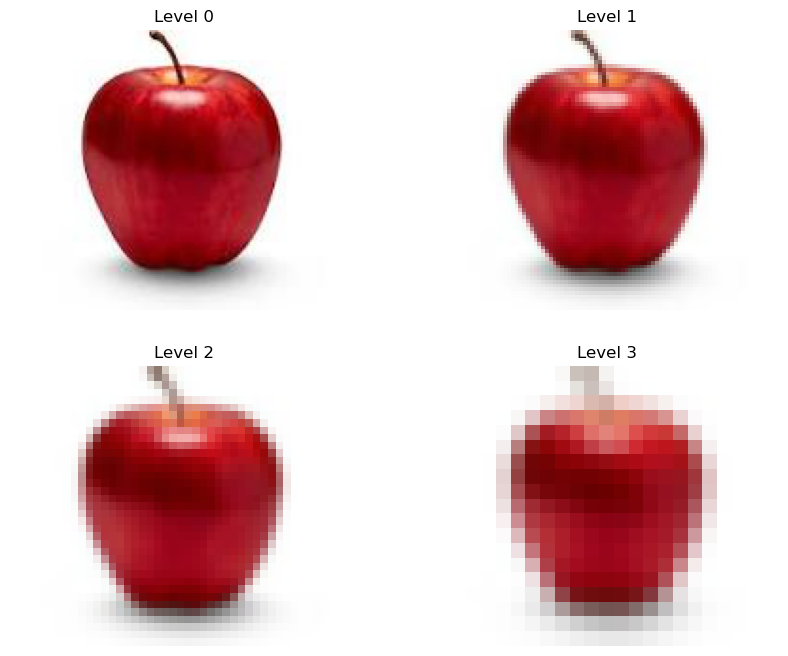

(148, 181, 3)
(74, 91, 3)
(37, 46, 3)
(19, 23, 3)


In [1]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("apple.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

level0 = img
level1 = cv2.pyrDown(level0)
level2 = cv2.pyrDown(level1)
level3 = cv2.pyrDown(level2)

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(level0)
plt.title("Level 0")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(level1)
plt.title("Level 1")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(level2)
plt.title("Level 2")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(level3)
plt.title("Level 3")
plt.axis("off")

plt.show()

print(level0.shape)
print(level1.shape)
print(level2.shape)
print(level3.shape)

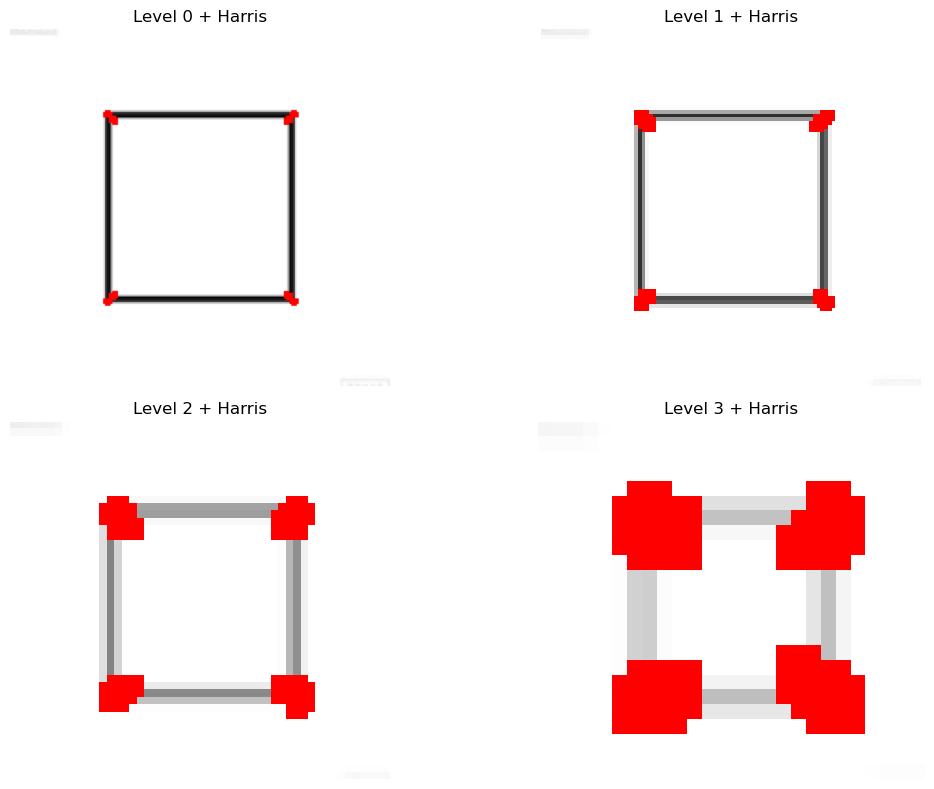

In [5]:
import cv2
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("sqaure.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


level0 = gray
level1 = cv2.pyrDown(level0)
level2 = cv2.pyrDown(level1)
level3 = cv2.pyrDown(level2)


def harris_corners(image):

    # Convert to float32
    gray_float = cv2.convertScaleAbs(image).astype("float32")

    # Harris Corner Detection
    R = cv2.cornerHarris(
        gray_float,
        blockSize=2,
        ksize=3, 
        k=0.04#Harris sensitivity constant R.
    )
#Smaller k → generally more sensitive to corner responses.
#Larger k → generally more selective about what counts as a corner.
#0.04 is a common/default-type value used for Harris corner detection.
    # Dilate response for visualization

        #This makes the detected regions a little bigger/thicker.
#It's mainly for visualization.
    R = cv2.dilate(R, None)

    # Convert grayscale image to RGB
    result = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

#Harris produces lots of values.

# You don't want to mark every tiny response as a corner.

# So you say:

# Only consider points whose Harris response is greater than 1% of the maximum response.
    # Threshold
    threshold = 0.01 * R.max()

    # Mark corners in red
    result[R > threshold] = [255, 0, 0]

    return result


result0 = harris_corners(level0)
result1 = harris_corners(level1)
result2 = harris_corners(level2)
result3 = harris_corners(level3)


plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(result0)
plt.title("Level 0 + Harris")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(result1)
plt.title("Level 1 + Harris")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(result2)
plt.title("Level 2 + Harris")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(result3)
plt.title("Level 3 + Harris")
plt.axis("off")

plt.tight_layout()
plt.show()

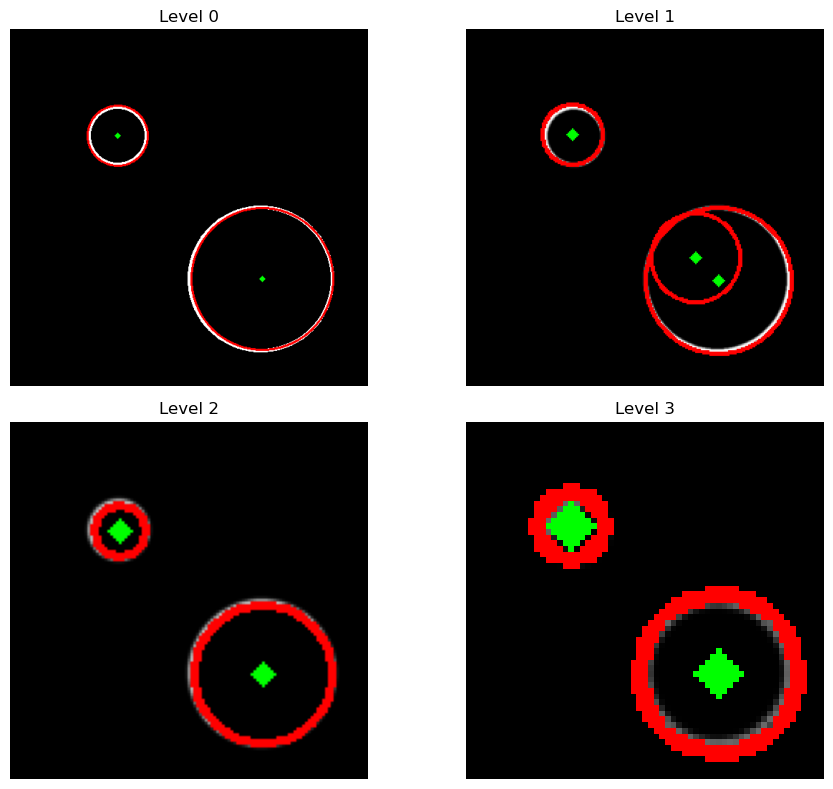

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = np.zeros((500, 500), dtype=np.uint8)

# Small circle
# img,        # image
#     (150,150),  # center
#     40,         # radius
#     255,        # color
#     3           # thickness
# )
cv2.circle(img, (150, 150), 40, 255, 3)

# Large circle
cv2.circle(img, (350, 350), 100, 255, 3)



level0 = img
level1 = cv2.pyrDown(level0)
level2 = cv2.pyrDown(level1)
level3 = cv2.pyrDown(level2)

def detect_circles(image):

    circles = cv2.HoughCircles(
        image,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=20,
        param1=100,
        param2=20,
        minRadius=5,
        maxRadius=100
    )

    result = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    if circles is not None:

        circles = np.uint16(np.around(circles))
#circle[0] means take first dimension from array
        for x, y, r in circles[0]:

            cv2.circle(result, (x, y), r, (255, 0, 0), 2)
            #This line draws a small green circle at the center of the detected circle:
            # image
            # (x, y),       # center position
            # 2,            # radius
            # (0, 255, 0),  # color
            # 3             # thickness
            cv2.circle(result, (x, y), 2, (0, 255, 0), 3)

    return result

result0 = detect_circles(level0)
result1 = detect_circles(level1)
result2 = detect_circles(level2)
result3 = detect_circles(level3)
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(result0)
plt.title("Level 0")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(result1)
plt.title("Level 1")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(result2)
plt.title("Level 2")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(result3)
plt.title("Level 3")
plt.axis("off")

plt.tight_layout()
plt.show()

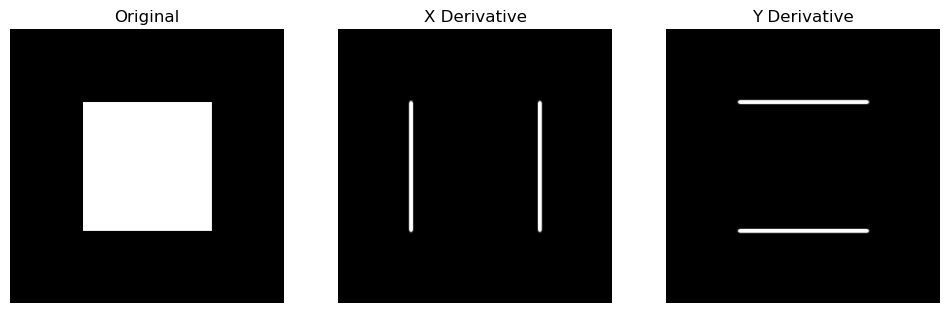

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = np.zeros((300, 300), dtype=np.uint8)

# White rectangle
cv2.rectangle(img, (80, 80), (220, 220), 255, -1)

blur = cv2.GaussianBlur(img, (5, 5), 1)

dx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
dy = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)

dx = cv2.convertScaleAbs(dx)
dy = cv2.convertScaleAbs(dy)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(dx, cmap="gray")
plt.title("X Derivative")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(dy, cmap="gray")
plt.title("Y Derivative")
plt.axis("off")

plt.show()

In [1]:
import cv2
import numpy as np

# Read image
img = cv2.imread("apple.jpg")

# Get image size
height, width = img.shape[:2]

# ==================================================
# 1. TRANSLATION
# ==================================================

tx = 100   # move right
ty = 50    # move down

translation_matrix = np.float32([
    [1, 0, tx],
    [0, 1, ty]
])

# [ 1   0   tx ]
# [ 0   1   ty ]
# #   ↑   ↑    ↑
#1 means keep x keep x as x and y as y
# 100 → move 100 pixels right
#50 → move 50 pixels down
#simply creates the matrix OpenCV needs to move the image.
translated = cv2.warpAffine(
    img,
    translation_matrix,
    (width, height)
)
# ==================================================
# 2. ROTATION
# ==================================================
angle = 45

rotation_matrix = cv2.getRotationMatrix2D(
    (width // 2, height // 2),
    angle,
    1
)
#means don't change the size.
# scale = 1     → same size
# scale = 2     → 2× larger
# scale = 0.5   → half the size
rotated = cv2.warpAffine(
    img,
    rotation_matrix,
    (width, height)
)
# ==================================================
# 3. SCALING
# ==================================================
scaled = cv2.resize(
    img,
    None,
    fx=2,
    fy=2
)
# ==================================================
# 4. REFLECTION
# ==================================================

# 1 = horizontal flip
# 0 = vertical flip
reflected = cv2.flip(img, 1)

# ==================================================
# 5. SHEARING
# ==================================================

shear = 0.5

shear_matrix = np.float32([
    [1, shear, 0],
    [0, 1,     0]#Y stays same
])


# [ 1    sh_x    0 ]
#   ↑     ↑      ↑
#   │     │      │
#   │     │      └── Translation (none)
#   │     └───────── Shearing amount
#   └─────────────── Keep original x

# 0 → don't take anything from x
# 1 → keep y as it is
# 0 → don't add any extra movement
sheared = cv2.warpAffine(
    img,
    shear_matrix,
    (width, height)
)

# ==================================================
# DISPLAY ALL RESULTS
# ==================================================

cv2.imshow("Original", img)
cv2.imshow("Translation", translated)
cv2.imshow("Rotation", rotated)
cv2.imshow("Scaling", scaled)
cv2.imshow("Reflection", reflected)
cv2.imshow("Shearing", sheared)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [1]:
import cv2
import numpy as np

image = cv2.imread("apple.jpg")

height, width = image.shape[:2]

angle = 45
theta = np.radians(angle)
#45 degrees → 0.785 radians
cos = np.cos(theta)
sin = np.sin(theta)
# cos(45°) ≈ 0.707
# sin(45°) ≈ 0.707

cx = width // 2
cy = height // 2
# width  = 800
# height = 600
# cx = 400
# cy = 300
1 2 3
4 5 6
7 8 9

0 0 0
0 0 0
0 0 0

# Create an empty image
#This creates a blank image having the same size and type as the original.
rotated = np.zeros_like(image)

for y in range(height):
    for x in range(width):

        new_x = int((x-cx)*cos - (y-cy)*sin + cx)
        new_y = int((x-cx)*sin + (y-cy)*cos + cy)

        if 0 <= new_x < width and 0 <= new_y < height:
            rotated[new_y, new_x] = image[y, x]

cv2.imshow("Rotated", rotated)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [1]:
# image add
import cv2
import numpy as np

img1 = cv2.imread("left.jpg")
img2 = cv2.imread("apple.jpg")
img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))
height, width = img1.shape[:2]

result = np.zeros_like(img1)

for y in range(height):
    for x in range(width):
        result[y, x] = np.clip(
            img1[y, x].astype(int) + img2[y, x].astype(int),
            0, 255
        )

cv2.imshow("Addition", result)
cv2.waitKey(0)
print(img1.shape)
print(img2.shape)

(860, 1294, 3)
(860, 1294, 3)


In [1]:
# image sub
import cv2
import numpy as np

img1 = cv2.imread("left.jpg")
img2 = cv2.imread("apple.jpg")
img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))
height, width = img1.shape[:2]

result = np.zeros_like(img1)

for y in range(height):
    for x in range(width):
        result[y, x] = np.clip(
            img1[y, x].astype(int) - img2[y, x].astype(int),
            0, 255
        )

cv2.imshow("Subtract", result)
cv2.waitKey(0)
print(img1.shape)
print(img2.shape)

(860, 1294, 3)
(860, 1294, 3)


In [4]:
# Image Averaging
# image sub
import cv2
import numpy as np

img1 = cv2.imread("left.jpg")
img2 = cv2.imread("apple.jpg")
img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))
height, width = img1.shape[:2]

result = np.zeros_like(img1)

for y in range(height):
    for x in range(width):
        result[y, x] = (
            img1[y, x].astype(int) +
            img2[y, x].astype(int)
        ) // 2

cv2.imshow("average", result)
cv2.waitKey(0)
print(img1.shape)
print(img2.shape)

(860, 1294, 3)
(860, 1294, 3)


In [3]:
img = cv2.imread("apple.jpg")

height, width = img.shape[:2]

result = np.zeros_like(img)

for y in range(height):
    for x in range(width):
        result[y, x] = 255 - img[y, x]

cv2.imshow("Negative", result)
cv2.waitKey(0)

-1